### Importando as Bibliotecas

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input, Flatten, Reshape
from sklearn.preprocessing import MinMaxScaler

# 1. SIMULAÇÃO REALISTA DE DADOS BASEADA NAS ESTATÍSTICAS DO UK-DALE

In [15]:
np.random.seed(42)
n_samples = 10000  # Equivalente a ~16 horas de leituras a cada 6s

# Dados normais: Consumo basal (50W-150W) + Ciclos normais de eletrodomésticos (geladeira, etc.)

In [16]:
base_consumption = np.random.normal(loc=100, scale=15, size=n_samples)
appliance_cycles = 500 * np.sin(np.linspace(0, 50, n_samples))**2  # Picos normais cotidianos
normal_data = base_consumption + appliance_cycles
normal_data = np.clip(normal_data, 50, 2500) # Mantém limites normais

# Injeção de uma anomalia severa no final dos dados de teste (ex: equipamento esquecido ligado ou curto)

In [17]:
anomaly_start = 8500
anomaly_end = 9500
test_data = normal_data.copy()
test_data[anomaly_start:anomaly_end] += np.random.normal(loc=4500, scale=200, size=anomaly_end-anomaly_start) # Salto para ~5000W

# 2. PRÉ-PROCESSAMENTO: NORMALIZAÇÃO MIN-MAX (0W a 8500W conforme o artigo)

In [18]:
X_min, X_max = 0, 8500
normal_data_scaled = (normal_data - X_min) / (X_max - X_min)
test_data_scaled = (test_data - X_min) / (X_max - X_min)

# 3. JANELAMENTO MÓVEL (SLIDING WINDOW) - JANELAS DE 60 LEITURAS (6 MINUTOS)

In [19]:
def create_windows(data, window_size=60):
    windows = []
    for i in range(len(data) - window_size):
        windows.append(data[i:(i + window_size)])
    return np.array(windows).reshape(-1, window_size, 1)

X_train = create_windows(normal_data_scaled)  # Treina APENAS com comportamento normal
X_test = create_windows(test_data_scaled)    # Teste contém a anomalia oculta

print(f"Formato dos dados de Treino: {X_train.shape}")
print(f"Formato dos dados de Teste: {X_test.shape}")

Formato dos dados de Treino: (9940, 60, 1)
Formato dos dados de Teste: (9940, 60, 1)


# 4. IMPLEMENTAÇÃO DA ARQUITETURA DO AUTOENCODER MLP (CONFORME O ARTIGO)

In [20]:
model = Sequential([
    Input(shape=(60, 1)),
    Flatten(),
    Dense(32, activation='relu', name='Encoder_Hidden'),
    Dense(8, activation='relu', name='Bottleneck'), # Espaço Latente Contraído
    Dense(32, activation='relu', name='Decoder_Hidden'),
    Dense(60, activation='sigmoid', name='Output_Layer'),
    Reshape((60, 1))
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Hidden (Dense)          │ (None, 32)             │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Bottleneck (Dense)              │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Hidden (Dense)          │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 60)             │         1,980 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 60, 1)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,484 (17.52 KB)

 Trainable params: 4,484 (17.52 KB)

 Non-trainable params: 0 (0.00 B)

# 5. TREINAMENTO DO MODELO (APIS TRADICIONAIS)

In [21]:
print("\nIniciando treinamento do modelo...")
history = model.fit(
    X_train, X_train,
    epochs=40,
    batch_size=64,
    validation_split=0.15,
    verbose=1
)


Iniciando treinamento do modelo...
Epoch 1/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0958 - val_loss: 0.0039
Epoch 2/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028 - val_loss: 0.0022
Epoch 3/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0021 - val_loss: 0.0021
Epoch 4/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020 - val_loss: 0.0021
Epoch 5/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020 - val_loss: 0.0020
Epoch 6/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019 - val_loss: 0.0020
Epoch 7/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019 - val_loss: 0.0020
Epoch 8/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019 - val_loss: 0.0020
Epoch 9/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019 - val_loss: 0.0019
Epoch 10/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018 - val_loss: 0.0018
Epoch 11/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 12/40
133/

# 6. DEFINIÇÃO DO LIMIAR ESTATÍSTICO DE ANOMALIA (THRESHOLD)

In [22]:
train_predictions = model.predict(X_train)
train_mae_loss = np.mean(np.abs(train_predictions - X_train), axis=(1, 2))
train_mse_loss = np.mean(np.square(train_predictions - X_train), axis=(1, 2))

mu_mse = np.mean(train_mse_loss)
sigma_mse = np.std(train_mse_loss)
threshold = mu_mse + 2 * sigma_mse
print(f"\nMédia do MSE (Treino): {mu_mse:.5f}")
print(f"Desvio Padrão do MSE (Treino): {sigma_mse:.5f}")
print(f"Limiar de Alerta Calculado (T): {threshold:.5f}")

311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Média do MSE (Treino): 0.00002
Desvio Padrão do MSE (Treino): 0.00001
Limiar de Alerta Calculado (T): 0.00004


# 7. AVALIAÇÃO EM DADOS DE TESTE (DETECÇÃO DA ANOMALIA)

In [23]:
test_predictions = model.predict(X_test)
test_mse_loss = np.mean(np.square(test_predictions - X_test), axis=(1, 2))

311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


# Identifica quais índices ultrapassaram a régua de segurança

In [24]:
anomalies_detected = test_mse_loss > threshold

# 8. GERAÇÃO DOS GRÁFICOS PARA O ARTIGO DO OVERLEAF

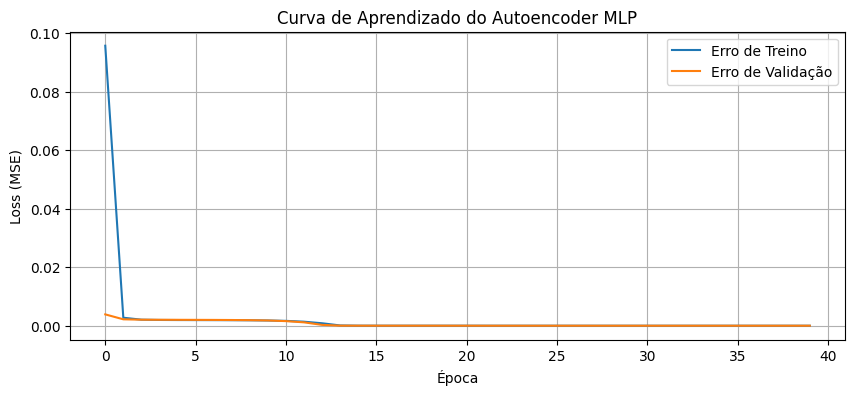

In [25]:
# Gráfico A: Curva de Perda (Loss por Época)
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Erro de Treino')
plt.plot(history.history['val_loss'], label='Erro de Validação')
plt.title('Curva de Aprendizado do Autoencoder MLP')
plt.xlabel('Época')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.savefig('loss_curve.png', dpi=300)
plt.show()

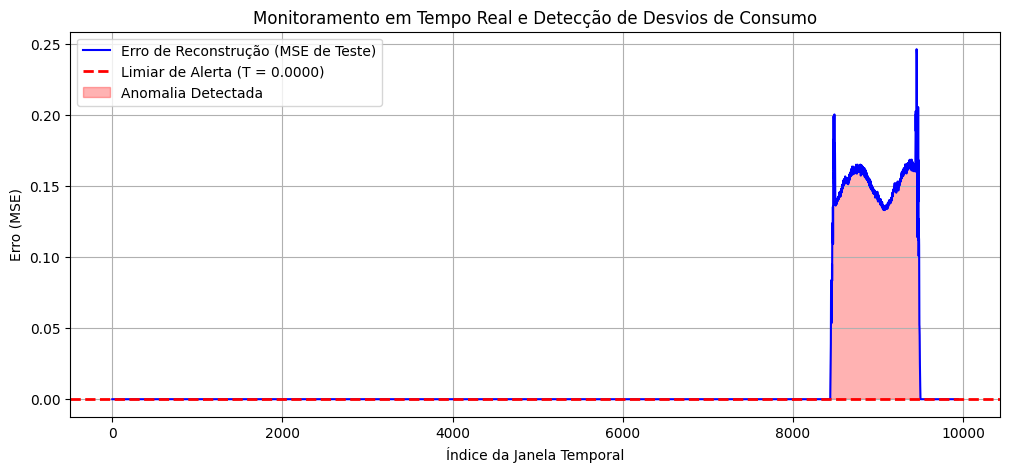

In [26]:
# Gráfico B: Detecção de Anomalias no Erro de Reconstrução
plt.figure(figsize=(12, 5))
plt.plot(test_mse_loss, label='Erro de Reconstrução (MSE de Teste)', color='blue')
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'Limiar de Alerta (T = {threshold:.4f})')
plt.fill_between(range(len(test_mse_loss)), 0, test_mse_loss, where=anomalies_detected, color='red', alpha=0.3, label='Anomalia Detectada')
plt.title('Monitoramento em Tempo Real e Detecção de Desvios de Consumo')
plt.xlabel('Índice da Janela Temporal')
plt.ylabel('Erro (MSE)')
plt.legend()
plt.grid(True)
plt.savefig('anomaly_detection.png', dpi=300)
plt.show()

# Exportando o Modelo (Quantização)

O modelo treinado é convertido para um arquivo .tflite de 8-bits (INT8).

In [27]:
import tensorflow as tf
import os

Converter o Keras Model para TensorFlow Lite com Quantização INT8.

In [28]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

Dataset representativo para calibrar a escala dos pesos (obrigatório para INT8).

In [29]:
def representative_data_gen():
    for input_value in tf.data.Dataset.from_tensor_slices(X_train).batch(1).take(100):
        yield [tf.cast(input_value, tf.float32)]

converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model_quant = converter.convert()

Saved artifact at '/tmp/tmp3i8x_g2x'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 60, 1), dtype=tf.float32, name='keras_tensor_7')
Output Type:
  TensorSpec(shape=(None, 60, 1), dtype=tf.float32, name=None)
Captures:
  136068347672720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136068347673680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136068347671376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136068347672528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136068347661392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136068347674064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136068347668112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136068347666192: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Salva o modelo.

In [30]:
with open('modelo_anomalia_quant.tflite', 'wb') as f:
    f.write(tflite_model_quant)

tamanho_kb = os.path.getsize("modelo_anomalia_quant.tflite") / 1024
print(f"Tamanho do modelo quantizado: {tamanho_kb:.2f} KB")

Tamanho do modelo quantizado: 12.42 KB
